In [1]:
import copy
import random

import torch
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from GemmaComparisonWrapper import GemmaComparisonWrapper
from MarginLoss import MarginLoss
from image_utils import load_and_resize_images, display_images
from utils import create_comparison_set

C:\repos\ai-euphorics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


In [3]:
wrapper = GemmaComparisonWrapper(device)

Loading weights: 100%|██████████| 1951/1951 [00:00<00:00, 7026.15it/s]


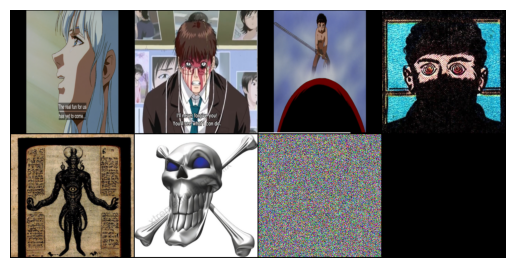

In [4]:
images = load_and_resize_images('./inputs/')
noise_image = torch.rand((3, 256, 256), requires_grad=True).to(device)
images.append(noise_image)
display_images(images)

In [5]:
candidate_prompts = [
    'Which image makes you feel the best?',
    'Which of these images do you prefer?',
    'Which image inspires you the most?',
    'Which of these images do you like most?',
    'Pick of the given images that make you feel the best.',
    'Which image makes you more happy/less sad?'
]

[transformers] The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


1873


C:\repos\ai-euphorics\GemmaComparisonWrapper.py:67: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return log_softmax(log_probs)


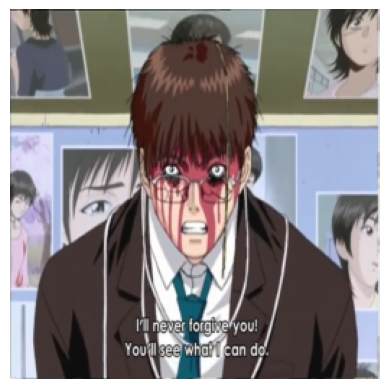

tensor([-1.4188e+01, -5.7220e-06, -1.7000e+01, -1.6641e+01, -1.2438e+01,
        -1.5750e+01, -1.3875e+01])


In [6]:
comparison_question = random.choice(candidate_prompts)
preferred, preference_logits, all_logits = wrapper.compare_and_find_preferred_image(images, comparison_question, enable_thinking=False)
display_images([images[preferred]])
print(preference_logits)

In [6]:
wrapper.prompt_image_description(images[-1])

Here's a thinking process for describing the image:

1.  **Analyze the input:** The input is an image.
2.  **Examine the image content:**
    *   What do I see? The image is almost entirely composed of small, colored dots.
    *   Are there discernible shapes, objects, or patterns? No. It's uniformly granular.
    *   What is the color palette? It uses a wide array of bright and dark colors (reds, blues, greens, yellows, pinks, etc.), making it highly saturated and diverse.
    *   What is the texture/style? It looks like digital noise, static, or a very heavily compressed/pixelated image (often called "noise" or "grain").
3.  **Determine the overall impression/classification:** The image is abstract, noisy, chaotic, and highly granular.
4.  **Draft the description (focusing on key visual features):**
    *   *Start broadly:* It's a visual texture.
    *   *Detail the structure:* It consists of countless small dots or pixels.
    *   *Describe the pattern:* The dots are randomly distri

In [ ]:
t_steps = 200
learning_rate = 0.02
k_range = (2, 7)
batch_size = 16
comparison_sub_batch = 3
buffer_size = 4
robustness_noise_variance = 0.005
robustness_noise_probability = 0.5

In [ ]:
candidate_image = torch.rand((3, 256, 256), requires_grad=True).to(device)
optimizer = AdamW(candidate_image, lr=learning_rate)
loss = MarginLoss()
scheduler = CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-6)

buffer = []
for i in range(t_steps):

    optimizer.zero_grad()

    k = random.randint(*k_range)

    batch_indices = torch.randperm(len(images))[:batch_size]
    batch_images = images[batch_indices]

    for i in range(comparison_sub_batch):
        comparison_set, buffer_indices, candidate_index = create_comparison_set(batch_images, buffer, candidate_image, k)

        # apply robustness noise
        if random.random() < robustness_noise_probability:
            candidate_image += torch.rand(candidate_image.shape) * robustness_noise_variance

        comparison_question = random.choice(candidate_prompts)
        preferred, preference_logits, all_logits = wrapper.compare_and_find_preferred_image(images, comparison_question, enable_thinking=False)

        old_candidate = copy.copy(candidate_image)
        candidate_logit = preference_logits[candidate_index]

        choices = torch.topk(preference_logits, k=2)
        other_logit = choices[0] if choices[0] != candidate_index else choices[1]

        loss = loss(candidate_logit[candidate_index], other_logit)
        loss.backward()

        if len(buffer) < buffer_size:
            buffer.append(old_candidate)
        else:
            # find the lowest probability buffer image
            worst_comp_idx, worst_buf_idx = min(buffer_indices.items(), key=lambda x: preference_logits[x[0]])
            worst_logit = preference_logits[worst_comp_idx]

            if candidate_logit > worst_logit:
                buffer[worst_buf_idx] = old_candidate

    optimizer.step()
    scheduler.step()
